# 🌱 Crop Recommendation System

## CodeAlpha Machine Learning Internship

### Project Description

This machine learning project predicts the most suitable crop based on soil nutrients and environmental conditions.

### Features Used

- Nitrogen (N)
- Phosphorus (P)
- Potassium (K)
- Temperature
- Humidity
- pH
- Rainfall

### Target

Crop Label

### Algorithms Used

- Decision Tree
- Random Forest
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine

Author: Krantikumar Patil

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_style("whitegrid")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
# ==========================================================
# Create Images Folder
# All generated graphs will be stored here.
# ==========================================================

import os

os.makedirs("images", exist_ok=True)

print("Images folder created successfully.")

Images folder created successfully.


In [5]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Task/Crop_recommendation.csv")

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


In [6]:
# ==========================================================
# Display First Five Records
# ==========================================================

df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
# ==========================================================
# Display Last Five Records
# ==========================================================

df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [8]:
# ==========================================================
# Display Dataset Shape
# ==========================================================

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2200
Number of Columns : 8


In [9]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [10]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
# ==========================================================
# Check Data Types
# ==========================================================

df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [12]:
# ==========================================================
# Check Missing Values
# ==========================================================

df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [13]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [14]:
# ==========================================================
# Display Column Names
# ==========================================================

df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [15]:
# ==========================================================
# Display Crop Categories
# ==========================================================

print(df['label'].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [16]:
# ==========================================================
# Total Number of Crop Types
# ==========================================================

print("Number of Crop Types :", df['label'].nunique())

Number of Crop Types : 22


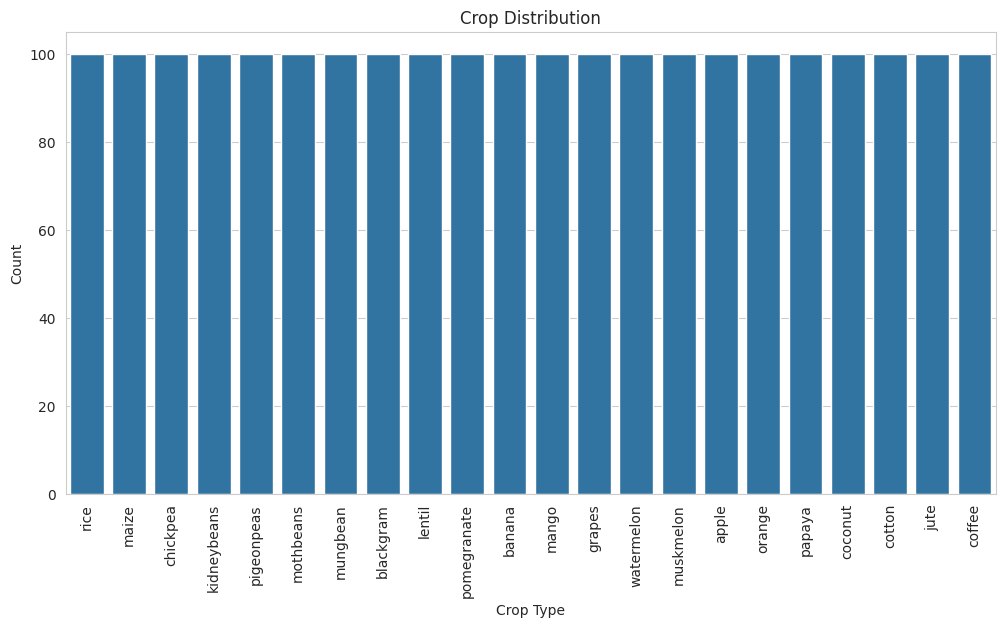

In [17]:
# ==========================================================
# Crop Distribution
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    x='label',
    data=df,
    order=df['label'].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Crop Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")

plt.savefig(
    "images/crop_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

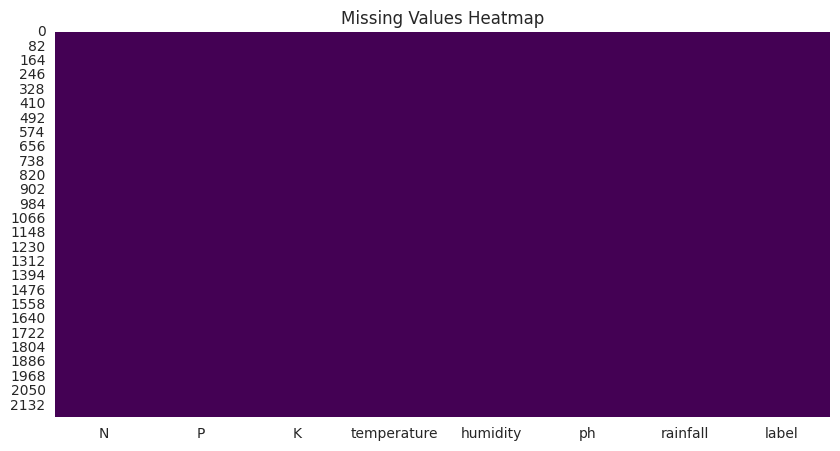

In [18]:
# ==========================================================
# Missing Value Heatmap
# ==========================================================

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.savefig(
    "images/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

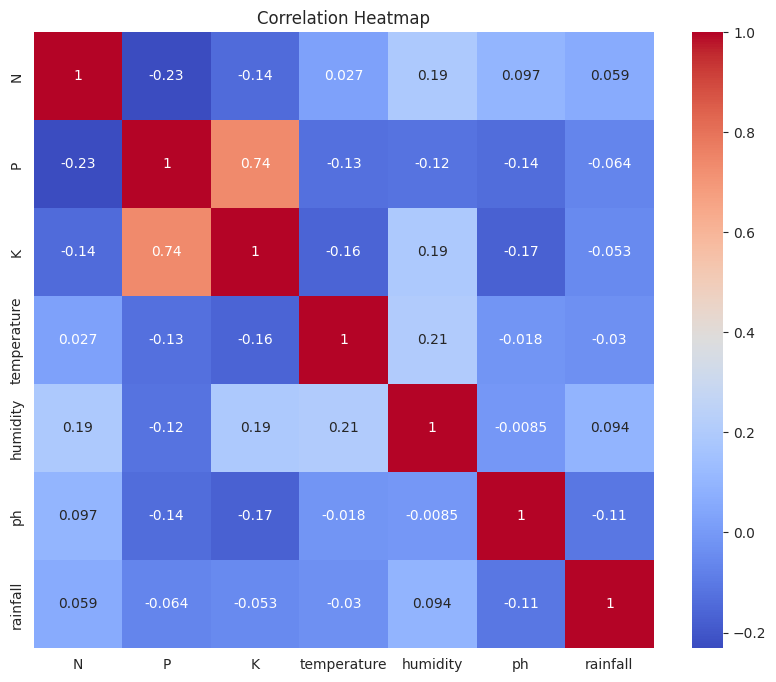

In [19]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("label", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


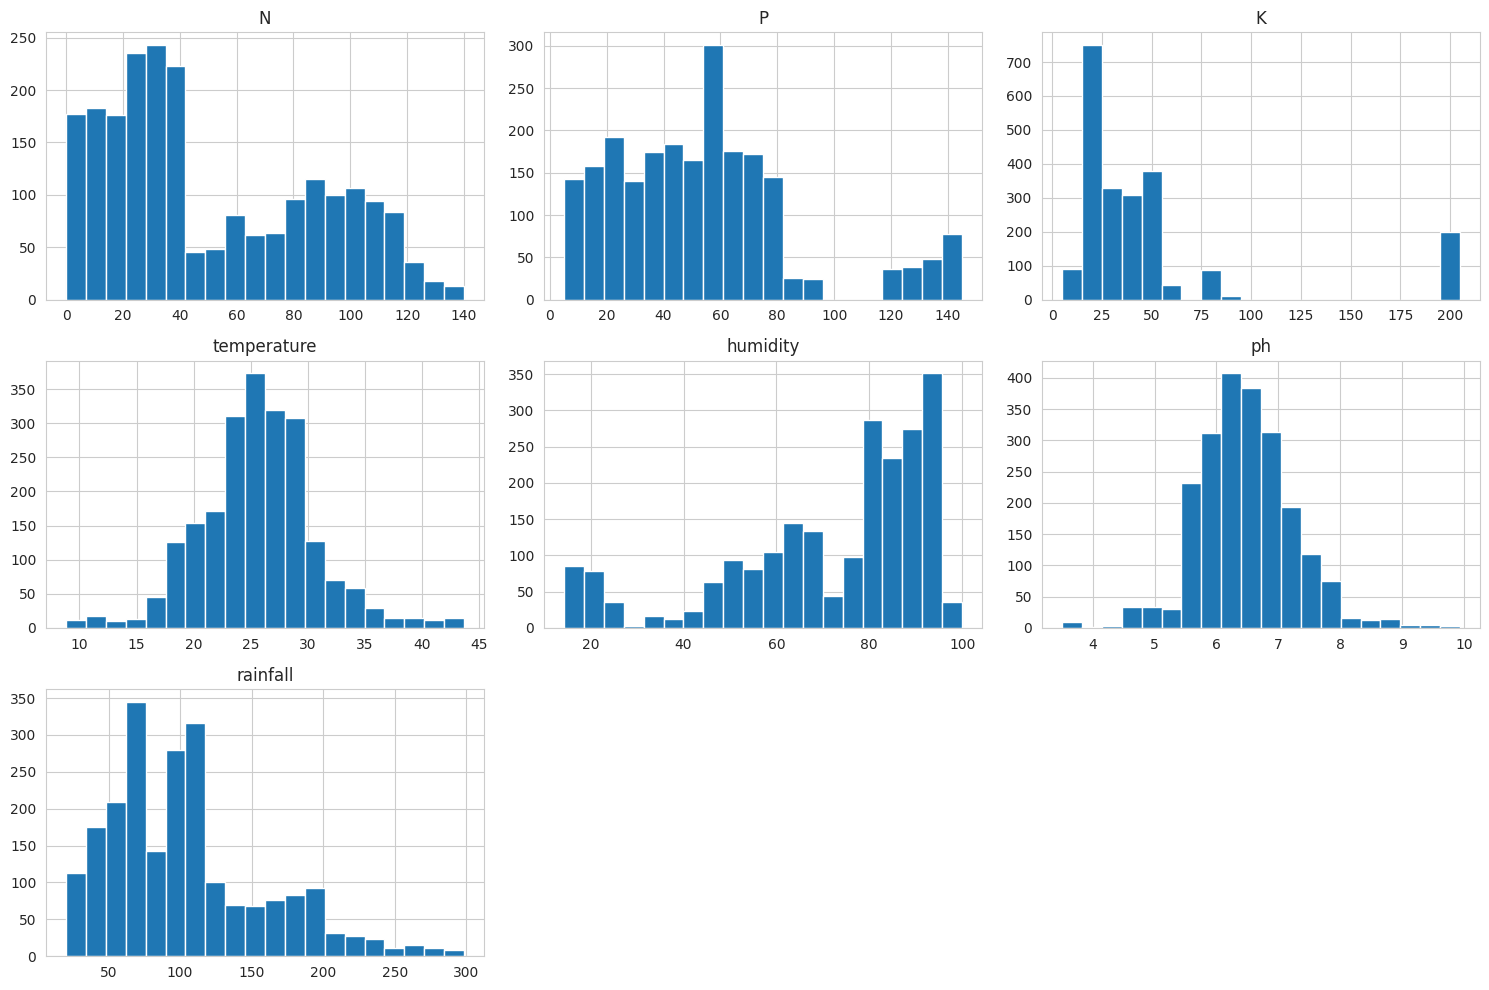

In [20]:
# ==========================================================
# Feature Distribution
# ==========================================================

df.drop("label", axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.savefig(
    "images/feature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

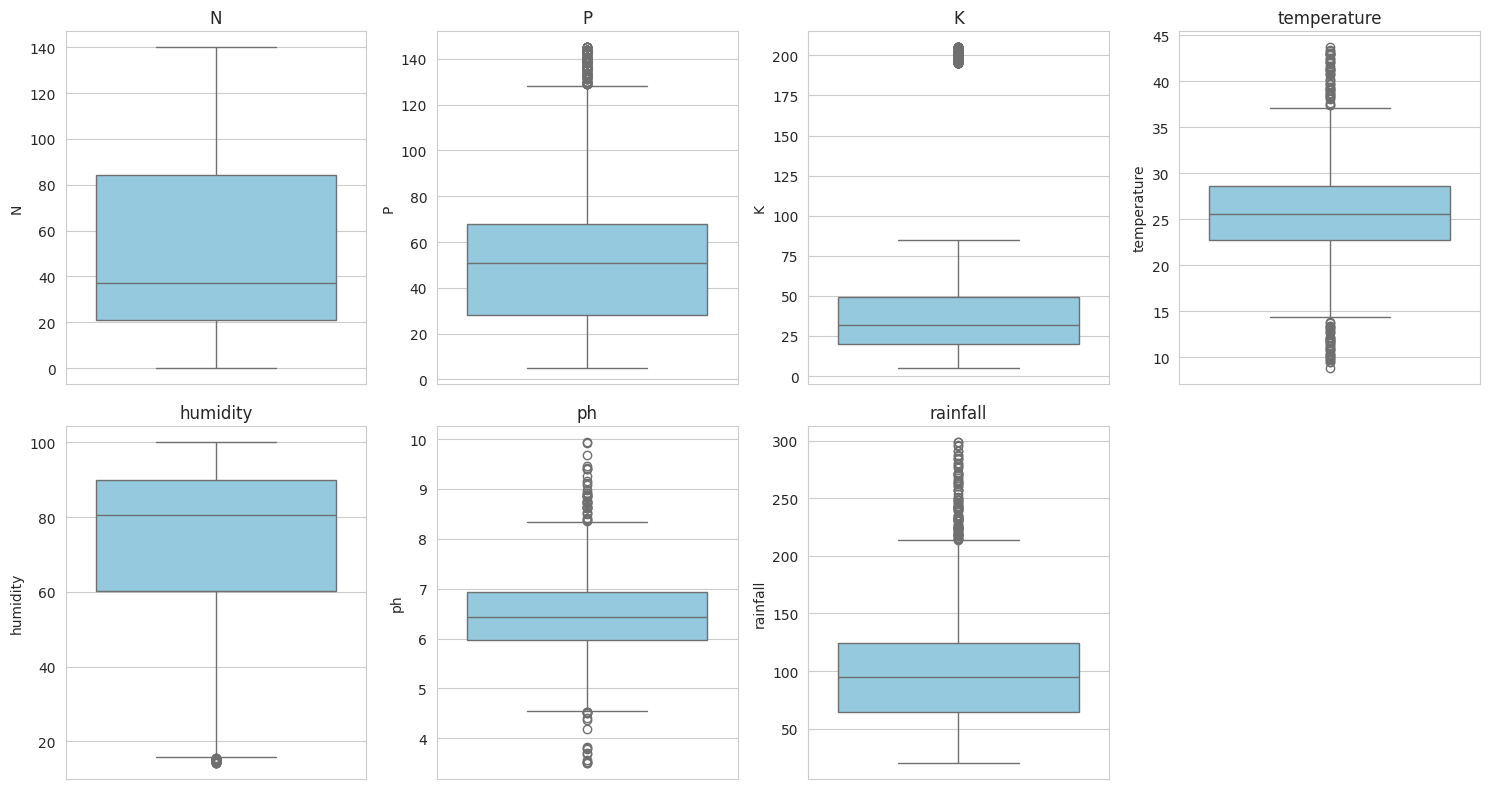

In [21]:
# ==========================================================
# Boxplots for Outlier Detection
# ==========================================================

plt.figure(figsize=(15,8))

for i, column in enumerate(df.columns[:-1]):

    plt.subplot(2,4,i+1)

    sns.boxplot(
        y=df[column],
        color="skyblue"
    )

    plt.title(column)

plt.tight_layout()

plt.savefig(
    "images/outlier_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

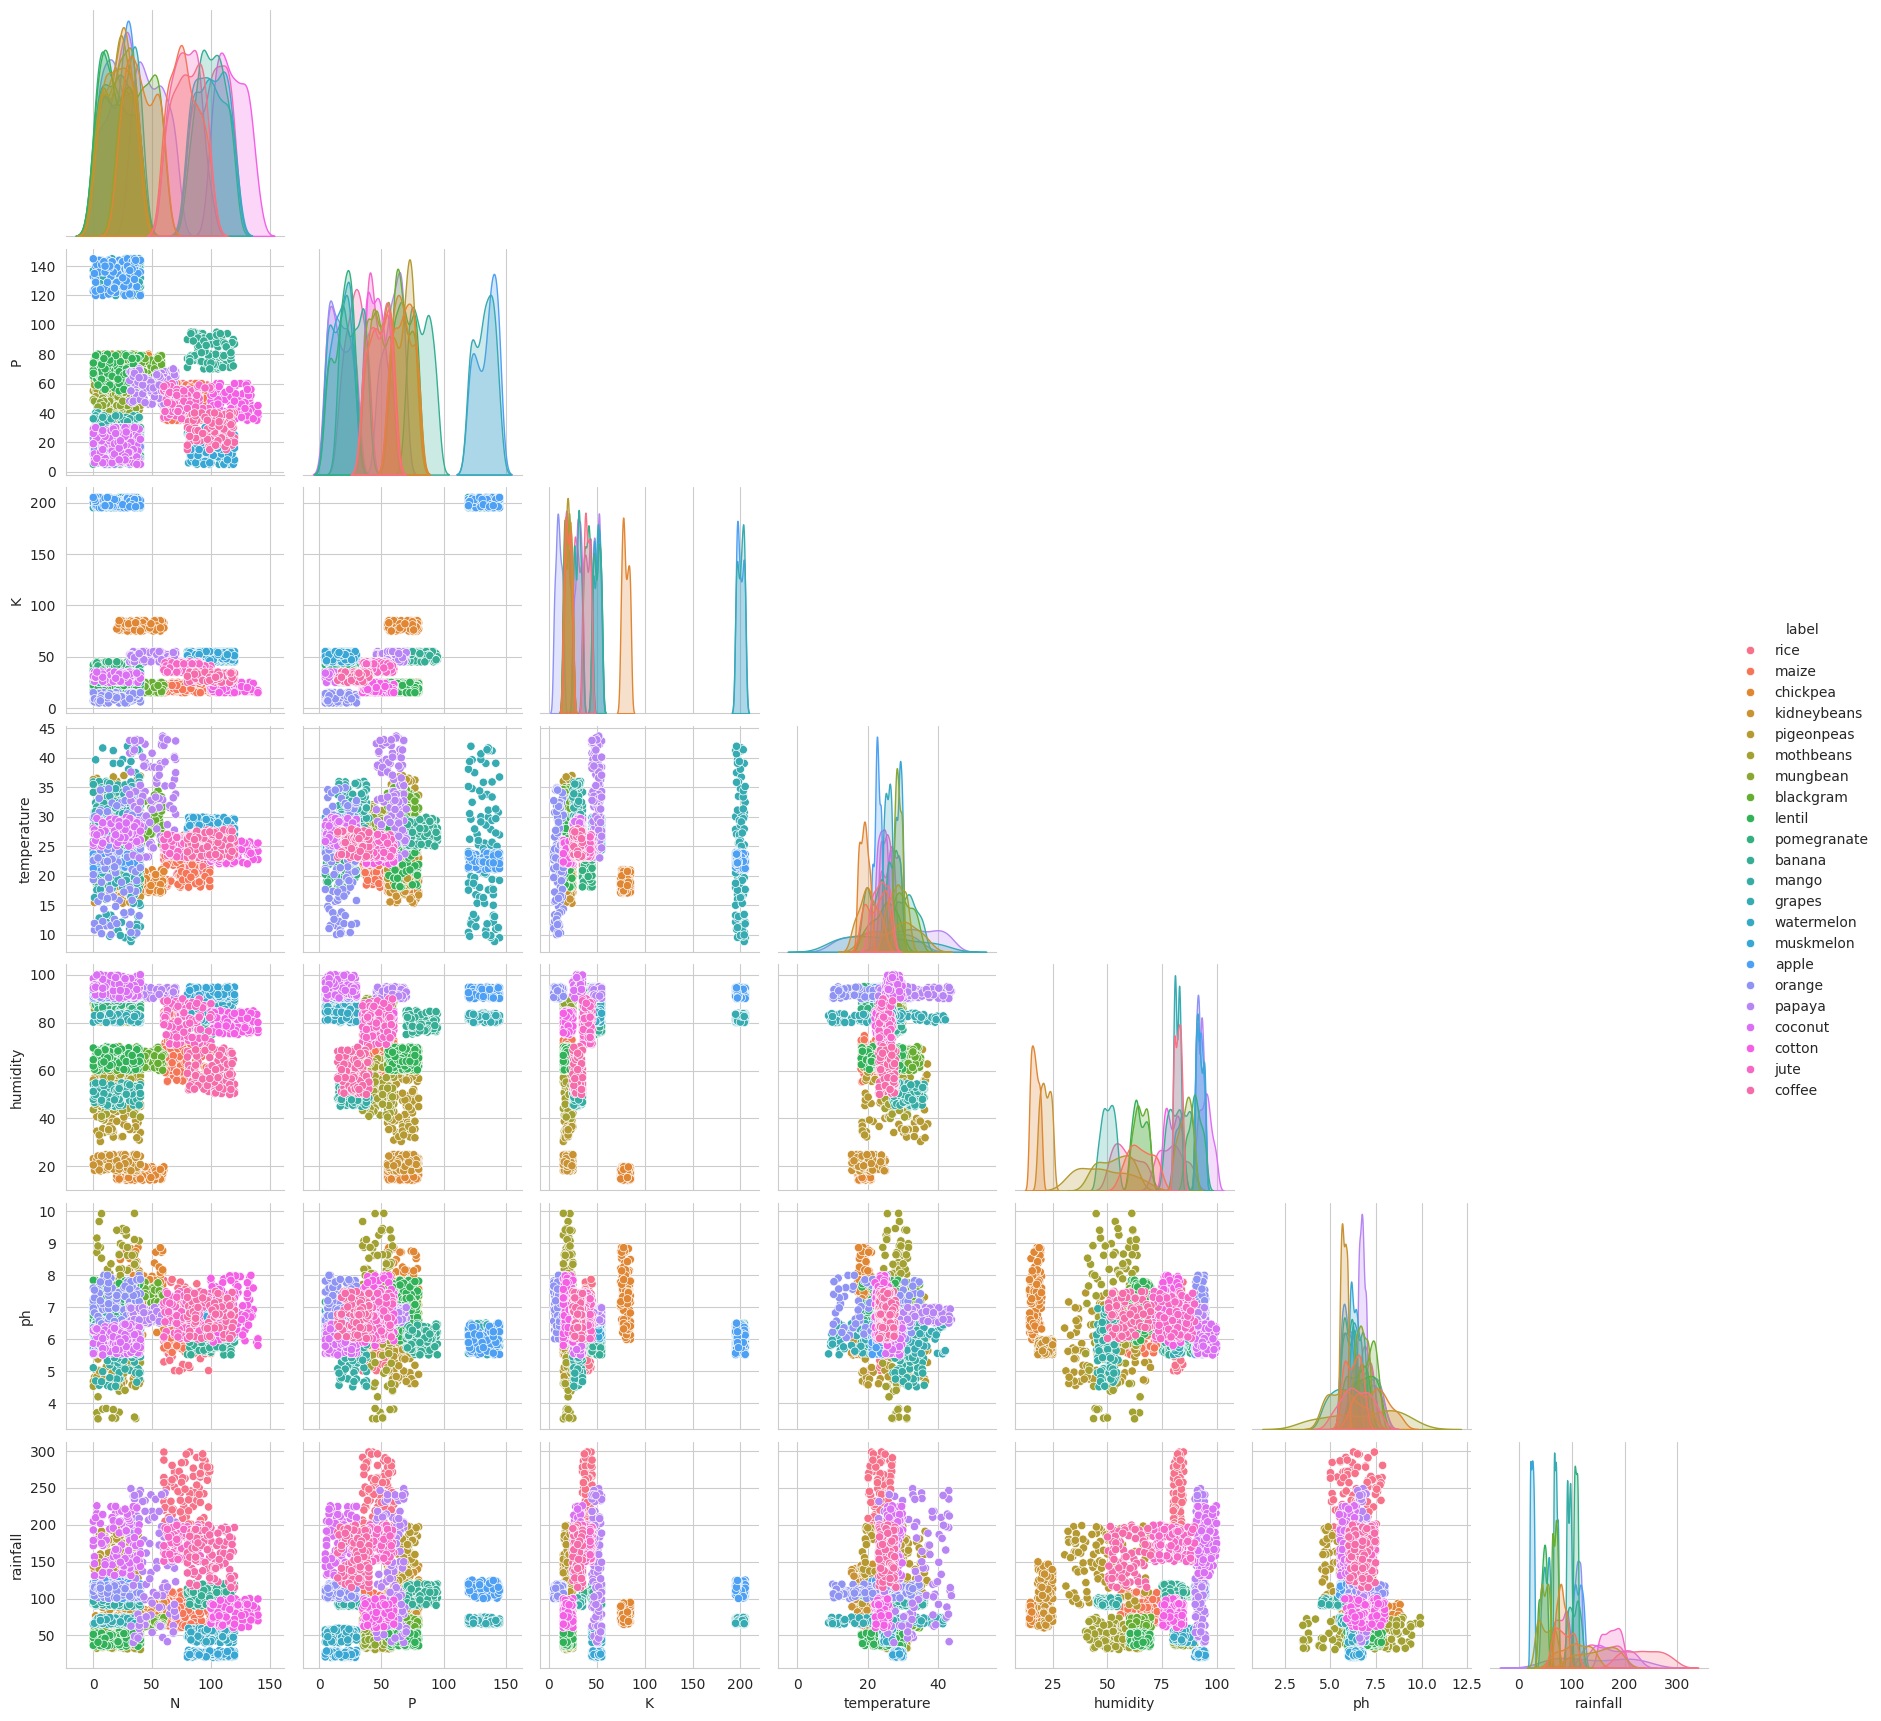

In [22]:
# ==========================================================
# Pairplot
# ==========================================================

pair = sns.pairplot(
    df,
    hue="label",
    corner=True
)

pair.savefig(
    "images/pairplot.png",
    dpi=300
)

plt.show()

In [23]:
# ==========================================================
# Average Feature Values
# ==========================================================

df.groupby("label").mean()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


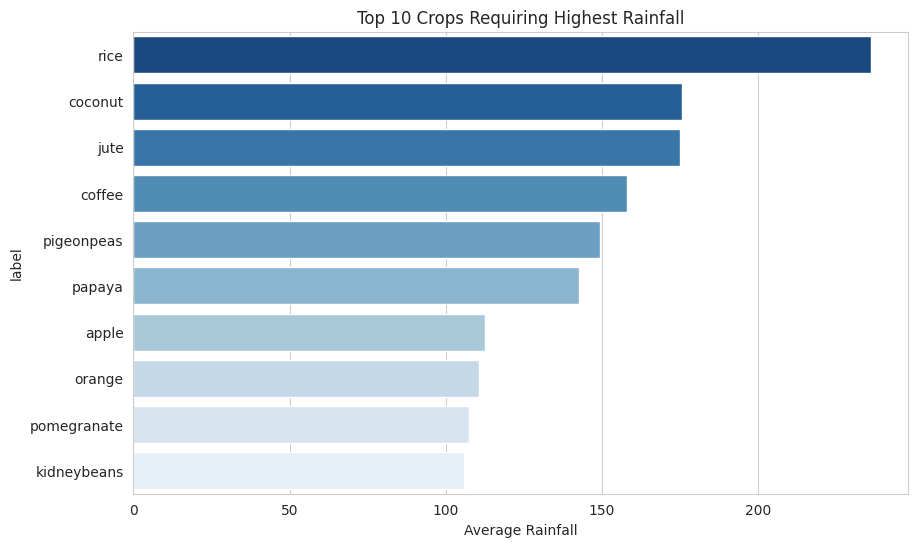

In [24]:
# ==========================================================
# Highest Rainfall Requirement
# ==========================================================

top_rain = df.groupby("label")["rainfall"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_rain.values[:10],
    y=top_rain.index[:10],
    palette="Blues_r"
)

plt.title("Top 10 Crops Requiring Highest Rainfall")

plt.xlabel("Average Rainfall")

plt.savefig(
    "images/high_rainfall_crops.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

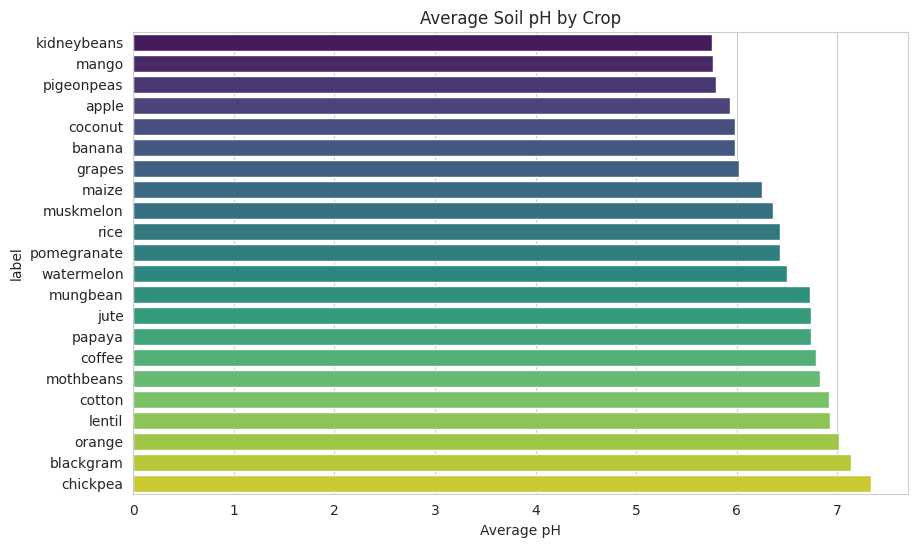

In [25]:
# ==========================================================
# Average Soil pH
# ==========================================================

ph = df.groupby("label")["ph"].mean().sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=ph.values,
    y=ph.index,
    palette="viridis"
)

plt.title("Average Soil pH by Crop")

plt.xlabel("Average pH")

plt.savefig(
    "images/ph_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

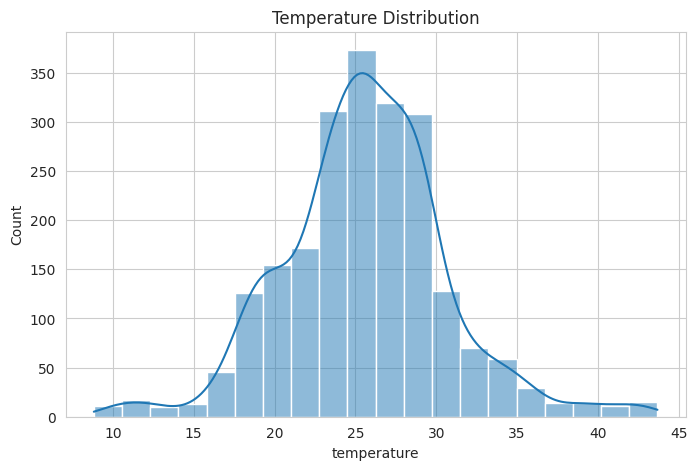

In [26]:
# ==========================================================
# Temperature Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df["temperature"],
    bins=20,
    kde=True
)

plt.title("Temperature Distribution")

plt.savefig(
    "images/temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# ==========================================================
# Import Machine Learning Libraries
# ==========================================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [28]:
# ==========================================================
# Convert Crop Labels into Numbers
# ==========================================================

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["label"])

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [29]:
# ==========================================================
# Select Features and Target Variable
# ==========================================================

X = df.drop("label", axis=1)

y = df["label"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (2200, 7)
Target Shape : (2200,)


In [30]:
# ==========================================================
# Standardize Features
# ==========================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [31]:
# ==========================================================
# Split Dataset into Training and Testing Sets
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (1760, 7)
Testing Samples : (440, 7)


In [32]:
# ==========================================================
# Decision Tree Classifier
# ==========================================================

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy :",

      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy : 0.9795454545454545


In [33]:
# ==========================================================
# Random Forest Classifier
# ==========================================================

rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy :",

      accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.9954545454545455


In [34]:
# ==========================================================
# Logistic Regression
# ==========================================================

lr = LogisticRegression(

    max_iter=500

)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy :",

      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy : 0.9727272727272728


In [35]:
# ==========================================================
# K Nearest Neighbor
# ==========================================================

knn = KNeighborsClassifier(

    n_neighbors=5

)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy :",

      accuracy_score(y_test, knn_pred))

KNN Accuracy : 0.9795454545454545


In [36]:
# ==========================================================
# Support Vector Machine
# ==========================================================

svm = SVC(

    kernel="rbf",

    random_state=42

)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy :",

      accuracy_score(y_test, svm_pred))

SVM Accuracy : 0.9840909090909091


In [37]:
# ==========================================================
# Evaluate All Models
# ==========================================================

models = {

    "Decision Tree":dt_pred,

    "Random Forest":rf_pred,

    "Logistic Regression":lr_pred,

    "KNN":knn_pred,

    "SVM":svm_pred

}

results=[]

for name,pred in models.items():

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(

            y_test,

            pred,

            average="weighted"

        ),

        "Recall":recall_score(

            y_test,

            pred,

            average="weighted"

        ),

        "F1 Score":f1_score(

            y_test,

            pred,

            average="weighted"

        )

    })

results=pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.979545,0.980598,0.979545,0.979423
1,Random Forest,0.995455,0.995671,0.995455,0.995452
2,Logistic Regression,0.972727,0.974022,0.972727,0.972464
3,KNN,0.979545,0.980356,0.979545,0.979283
4,SVM,0.984091,0.985610,0.984091,0.984038


In [38]:
# ==========================================================
# Display Best Performing Model
# ==========================================================

best_model = results.loc[

    results["Accuracy"].idxmax()

]

best_model

,1
Model,Random Forest
Accuracy,0.995455
Precision,0.995671
Recall,0.995455
F1 Score,0.995452


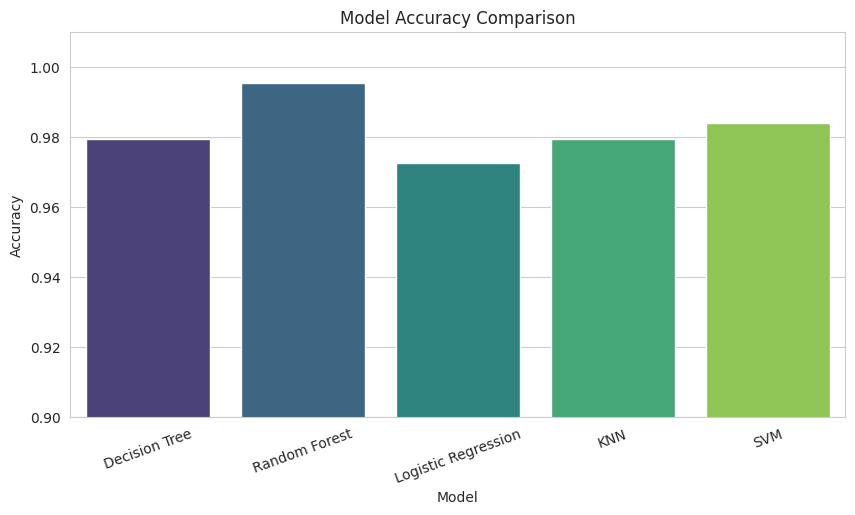

In [39]:
# ==========================================================
# Model Comparison
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Accuracy",

    palette="viridis"

)

plt.ylim(0.90,1.01)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.savefig(

    "images/accuracy_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [40]:
# ==========================================================
# Classification Report
# ==========================================================

print(

classification_report(

    y_test,

    rf_pred

)

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

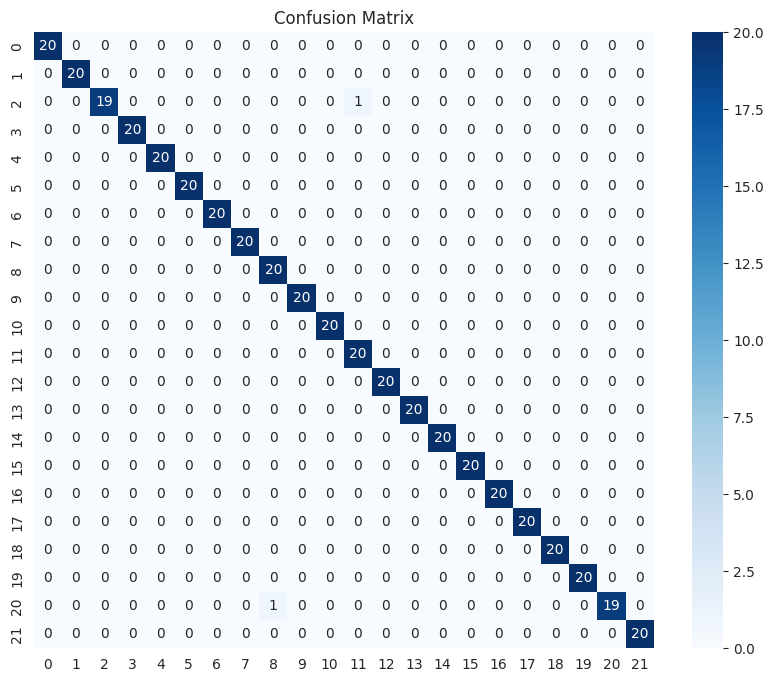

In [41]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(

    y_test,

    rf_pred

)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    cmap="Blues",

    annot=True,

    fmt="d"

)

plt.title("Confusion Matrix")

plt.savefig(

    "images/confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

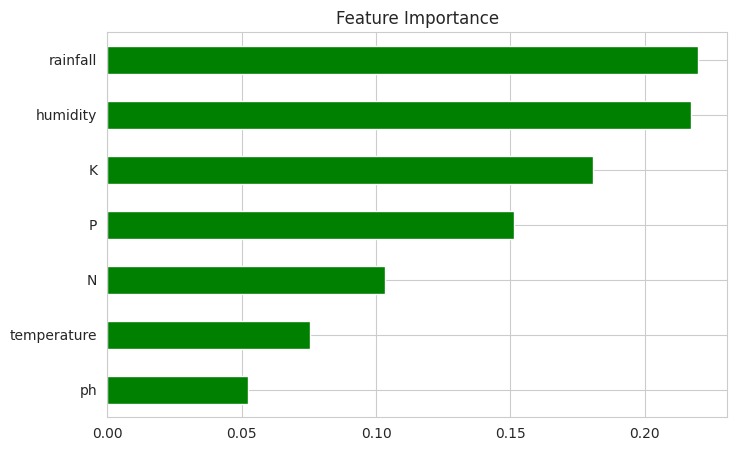

In [42]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.Series(

    rf.feature_importances_,

    index=df.columns[:-1]

)

importance.sort_values().plot(

    kind="barh",

    figsize=(8,5),

    color="green"

)

plt.title("Feature Importance")

plt.savefig(

    "images/feature_importance.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [43]:
# ==========================================================
# Predict Crop for New Data
# ==========================================================

sample = [[90,42,43,20.8,82,6.5,202]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

crop = encoder.inverse_transform(prediction)

print("Recommended Crop :", crop[0])

Recommended Crop : rice


In [44]:
# ==========================================================
# Hyperparameter Tuning using GridSearchCV
# ==========================================================

from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Accuracy:
0.9960227272727271


In [45]:
# ==========================================================
# Train Best Random Forest Model
# ==========================================================

best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

best_pred = best_rf.predict(X_test)

print("Test Accuracy :",
      accuracy_score(y_test, best_pred))

Test Accuracy : 0.9954545454545455


In [46]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(
    y_test,
    best_pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00    

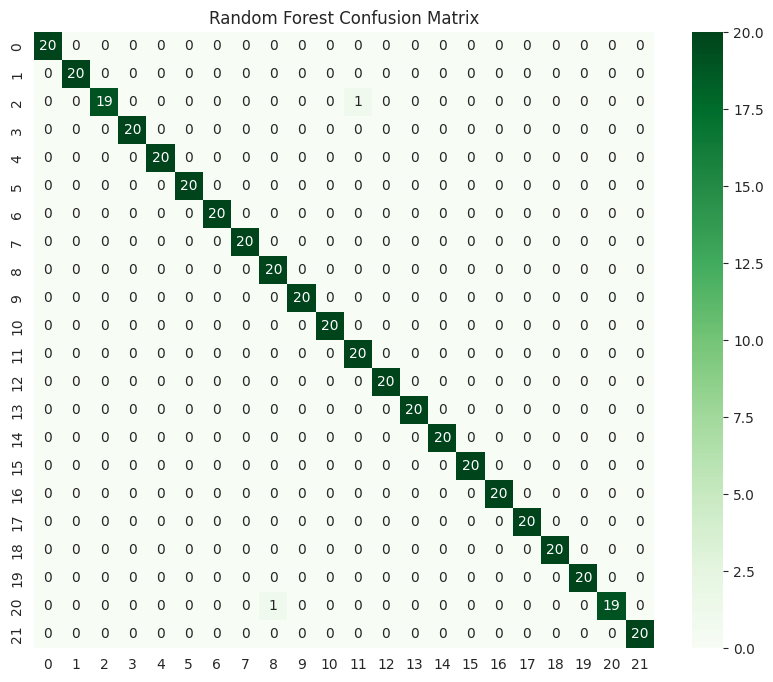

In [47]:
# ==========================================================
# Confusion Matrix of Best Model
# ==========================================================

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    cmap="Greens",
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "images/confusion_matrix_tuned.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

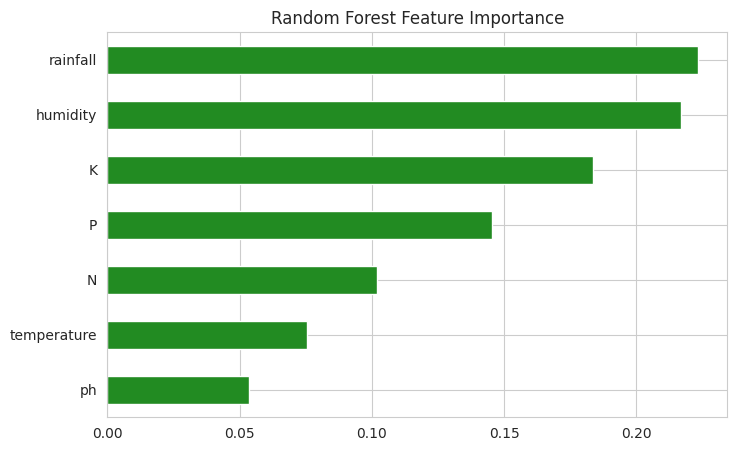

In [48]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.Series(
    best_rf.feature_importances_,
    index=df.columns[:-1]
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(
    kind="barh",
    color="forestgreen"
)

plt.title("Random Forest Feature Importance")

plt.savefig(
    "images/feature_importance_tuned.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# ==========================================================
# Predict Crop for New Farmer Data
# ==========================================================

sample = [[90,42,43,20.8,82,6.5,202]]

sample = scaler.transform(sample)

prediction = best_rf.predict(sample)

crop = encoder.inverse_transform(prediction)

print("Recommended Crop :", crop[0])

Recommended Crop : rice


In [50]:
# ==========================================================
# Final Performance Summary
# ==========================================================

performance = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,svm_pred)
    ]

})

performance.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
1,Random Forest,0.995455
4,SVM,0.984091
0,Decision Tree,0.979545
3,KNN,0.979545
2,Logistic Regression,0.972727


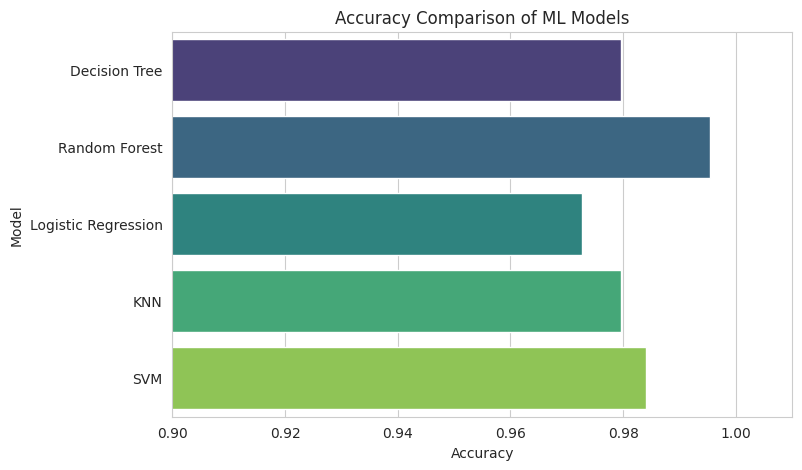

In [52]:
# ==========================================================
# Final Accuracy Comparison
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=performance,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Accuracy Comparison of ML Models")

plt.xlim(0.90,1.01)

plt.savefig(
    "images/model_accuracy_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()